# De-Identification of DICOM Data - Jupyter Notebook Tutorial

This script-style Jupyter notebook introduces researchers to Python-based tools for de-identifying DICOM data, referencing HIPAA Safe Harbor guidelines and PIPEDA.

It allows users to:
- Use either a sample or custom DICOM file
- Choose specific tags to clear, mask, or generalize
- Filter and batch process files from a folder

----
NOTE: This tutorial is for educational purposes only. It does not offer a de-identification service but shows you how to approach de-identification in your own research workflow.



# Install and Import Necessary Libraries


In [ ]:
!pip install pydicom #the ! will be removed when taken off colab
# pip install numpy --> commented until taken off of Colab
# pip install matplotlib --> commented until taken off of Colab
# pip install pillow --> commented until taken off of Colab
# pip install hashlib --> commented until taken off of Colab
# pip install glob --> commented until taken off of Colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.8 MB/s eta 0:00:00


In [ ]:
import os
import pydicom
from pydicom.data import get_testdata_files
from pydicom.uid import generate_uid
from hashlib import sha256
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import glob
import random

#Load helper utilities to show outputs from functions A-F (expand to see functions)

In [ ]:
# ---- Helper utilities for friendly demos (non-coder-friendly) ----
from pydicom.tag import Tag
from pydicom.datadict import tag_for_keyword, keyword_for_tag

def _resolve_tag(tag_like):
    """Accept 'PatientName', (0x0010,0x0010), [0x0010,0x0010], or pydicom Tag."""
    if isinstance(tag_like, Tag):
        return tag_like
    if isinstance(tag_like, (tuple, list)) and len(tag_like) == 2:
        return Tag(tag_like[0], tag_like[1])
    if isinstance(tag_like, str):
        # try keyword
        t = tag_for_keyword(tag_like)
        if t is not None:
            return Tag(t)
        # try hex string forms like "00100010" or "0010,0010"
        s = tag_like.replace(",", "").replace("(", "").replace(")", "").replace(" ", "").lower()
        if len(s) == 8 and all(c in "0123456789abcdef" for c in s):
            return Tag(int(s[:4], 16), int(s[4:], 16))
    raise ValueError(f"Unrecognized tag: {tag_like}")

def _label(tag):
    try:
        return f"({tag.group:04X},{tag.element:04X}) {keyword_for_tag(tag) or ''}".strip()
    except Exception:
        return str(tag)

def values_of(ds, tags):
    out = {}
    for t in tags:
        T = _resolve_tag(t)
        out[_label(T)] = str(ds[T].value) if T in ds else "<not present>"
    return out

def print_before_after(ds_before, ds_after, tags):
    print("BEFORE:")
    for k, v in values_of(ds_before, tags).items():
        print(f"  {k}: {v}")
    print("\nAFTER:")
    for k, v in values_of(ds_after, tags).items():
        print(f"  {k}: {v}")


from pydicom.tag import Tag
from pydicom.datadict import tag_for_keyword, keyword_for_tag

def _resolve_tag(tag_like):
    """
    Robustly convert many inputs → pydicom Tag:
      - 'PatientName' (keyword)
      - (0x0010,0x0010) or [0x0010,0x0010]
      - '00100010' or '0010,0010'
      - Tag / BaseTag / int-like accepted by Tag()
    """
    # 1) If Tag() can already handle it, use that path
    try:
        return Tag(tag_like)
    except Exception:
        pass

    # 2) tuple/list of two ints
    if isinstance(tag_like, (tuple, list)) and len(tag_like) == 2:
        return Tag(int(tag_like[0]), int(tag_like[1]))

    # 3) keyword or hex string
    if isinstance(tag_like, str):
        # try keyword
        t = tag_for_keyword(tag_like)
        if t is not None:
            return Tag(t)
        # try hex strings like "00100010" or "0010,0010"
        s = tag_like.replace(",", "").replace("(", "").replace(")", "").replace(" ", "").lower()
        if len(s) == 8 and all(c in "0123456789abcdef" for c in s):
            return Tag(int(s[:4], 16), int(s[4:], 16))

    raise ValueError(f"Unrecognized tag: {tag_like}")


# 1. Configuration --> edit this if you want to try the functions on your own DICOM file or use the pydicom sample file.

User can choose to use their own dicom image or use the pydicom sample image for processing.

In [ ]:
USE_SAMPLE = False  # Set to False if you want to use your own image
custom_path = "/content/11943782" # <-- update this path after dragging & dropping your dicom file into the Google Colab Files section.

if USE_SAMPLE:
    from pydicom.data import get_testdata_files
    dicom_path = get_testdata_files("CT_small.dcm")[0]
else:
    dicom_path = custom_path

ds = pydicom.dcmread(dicom_path) #dicom file to play with in the demos
ds_baseline = pydicom.dcmread(dicom_path)  # fresh, untouched copy for demos

# 2. HIPAA Safe Harbor Rule - Identifiers to Remove (expand to see the list)



The Safe Harbor method from HIPAA requires the removal of 18 identifiers. Some relevant ones for DICOM include:

1. Names
2. Geographic subdivisions smaller than a state
3. All elements of dates (except year)
4. Telephone numbers
5. Fax numbers
6. Email addresses
7. Social Security numbers
8. Medical record numbers (MRN)
9. Health plan beneficiary numbers
10. Account numbers
11. Certificate/license numbers
12. Vehicle identifiers
13. Device identifiers
14. URLs
15. IP addresses
16. Biometric identifiers
17. Full-face photos or comparable images
18. Any unique identifying number, characteristic, or code

These may correspond to the following DICOM tags:
- (0010,0010) PatientName
- (0008,0081) InstitutionAddress
- (0008,0022) Acquisition Date
- (0040,1103) PersonsTelephoneNumbers
- (0010,0020) PatientID
- (0010,1000) OtherPatientIDs
- (0010,0030) PatientBirthDate
- (0008,0090) ReferringPhysicianName
- (0008,0080) InstitutionName
- (0008,1070) OperatorsName
- (0018,1000) DeviceSerialNumber
- ... and many more


# 3. Load Sample DICOM File

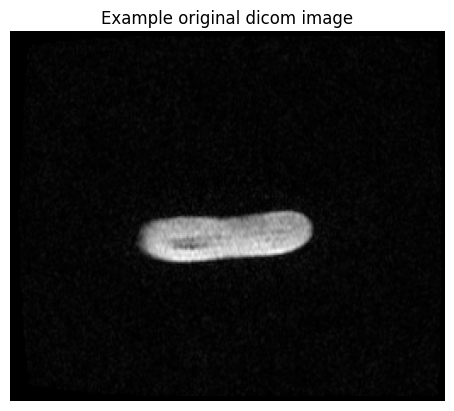

In [ ]:
img = ds_baseline.pixel_array

# Display the image
plt.imshow(img, cmap='gray')
plt.title("Example original dicom image")
plt.axis('off')
plt.show()

#4. Inspect PHI-Containing Metadata

A great resource to reference DICOM metadata tags can be found here: https:/www.dicomlibrary.com/dicom/dicom-tags/



Check your DICOM file carefully for all PHI-containing fields and correspond to this resource as a guideline.

In [ ]:
print("\n--- ALL METADATA BEFORE DE-IDENTIFICATION ---")
for elem in ds:
    if elem.VR != "OB" and elem.tag.group != 0x7FE0:
        print(f"{elem.tag} {elem.name}: {elem.value}")


--- ALL METADATA BEFORE DE-IDENTIFICATION ---
(0008,0005) Specific Character Set: ISO_IR 100
(0008,0008) Image Type: ['ORIGINAL', 'PRIMARY', 'M', 'DIS2D', 'MFSPLIT']
(0008,0012) Instance Creation Date: 20250408
(0008,0013) Instance Creation Time: 183949.960000
(0008,0016) SOP Class UID: 1.2.840.10008.5.1.4.1.1.4
(0008,0018) SOP Instance UID: 1.3.12.2.1107.5.2.18.41999.30000025040818522262800001018
(0008,0020) Study Date: 20250408
(0008,0021) Series Date: 20250408
(0008,0022) Acquisition Date: 20250408
(0008,0023) Content Date: 20250408
(0008,002A) Acquisition DateTime: 20250408183949.960000
(0008,0030) Study Time: 181318.500000
(0008,0031) Series Time: 183959.999000
(0008,0032) Acquisition Time: 183949.960000
(0008,0033) Content Time: 184025.809000
(0008,0050) Accession Number: 
(0008,0060) Modality: MR
(0008,0070) Manufacturer: Siemens Healthineers
(0008,0080) Institution Name: Heart Institute
(0008,0081) Institution Address: Ruskin Street 40,Ottawa,Eastern,CA,k1Y 4W7
(0008,0090) Ref

Metadata tags containing dates may include the following tags:

*   Study date
*   Series date
*   Acquisition date
*   ... and so on.


Below are some example metadata tags containing dates.
-----

**Please note that this is NOT a conclusive list** - there are up to 88 metadata tags that may contain dates. You should always carefully inspect your original (identified) image to determine all fields that contain dates.



In [ ]:
date_tags = {
    (0x0008, 0x0020): "Study Date",
    (0x0008, 0x0021): "Series Date",
    (0x0008, 0x0022): "Acquisition Date",
    (0x0008, 0x0023): "Content Date",
    (0x0008, 0x0012): "Instance Creation Date",
    (0x0018, 0x1012): "Date of Secondary Capture", # May not exist in all files
    (0x0040, 0x0244): "Performed Procedure Step Start Date",  # May not exist in all files
    (0x0010, 0x0030): "Patient Birth Date"
}


#Show the output of the above-listed date tags.
print('Output of the original dicom file "date_tags":')
for tag, label in date_tags.items():
    if tag in ds_baseline:
        print(f"{label}: {ds_baseline[tag].value}")
    else:
        print(f"{label}: (not found)")

Output of the original dicom file "date_tags":
Study Date: 20250408
Series Date: 20250408
Acquisition Date: 20250408
Content Date: 20250408
Instance Creation Date: 20250408
Date of Secondary Capture: (not found)
Performed Procedure Step Start Date: 20250408
Patient Birth Date: 20010101


#Mapping dictionary to define which tags you want to apply functions A-F to.

In [ ]:
# === Big configuration map: which tags to clear vs mask vs generalize vs pseudonymize vs noise ===
# People can edit this dictionary only, and then "apply plan" near the end.
DEID_MAP = {
    "clear": [
        # Examples: remove these fields entirely
        # "InstanceCreationDate",
        # "OperatorsName",
    ],
    "mask": {
        # Overwrite with a literal placeholder
        # "InstitutionName": "REDACTED HOSPITAL",
    },
    "generalize": {
        # Reduce specificity, e.g., keep year only
        # "PatientBirthDate": "keep_year",
    },
    "pseudonymize": [
        # Hash these identifiers (stable, non-reversible)
        # "PatientID",
    ],
    "noise": {
        # Add random perturbation. Example: ±2 years on StudyDate
        # "StudyDate": {"type": "date_shift", "range": 2}
    },
    "suppress_private": True,   # remove private/odd-group elements when applying plan
    "pixel_masks": [
        # Optional blackout boxes [x1, y1, x2, y2] for burned-in PHI in pixels
        # [5, 5, 200, 40],
    ],
    "salt": "ARCHIMEDES_DEMO_SALT"  # used for pseudonym hashing (optional)
}

# 5. Anonymization and Pseudonymization Options

# A. Direct Clearing of Tags (Anonymization)


*Anonymization* is the total removal of PHI - i.e., full deletion. It is often used for targeted clearing of known identifiers, such as the patient's name.

See below the python function followed by the demo.

In [ ]:
def clear_tags(ds, tags_to_clear):
    for tag in tags_to_clear:
        T = _resolve_tag(tag)
        if T in ds:
            del ds[T]
    return ds

In [ ]:
_demoA_before = ds_baseline.copy()
_demoA_after = ds.copy()
_demoA_after = clear_tags(_demoA_after, ["InstanceCreationDate"])
print("A) CLEAR example: remove InstanceCreationDate")
print_before_after(_demoA_before, _demoA_after, ["InstanceCreationDate"])


A) CLEAR example: remove InstanceCreationDate
BEFORE:
  (0008,0012) InstanceCreationDate: 20250408

AFTER:
  (0008,0012) InstanceCreationDate: <not present>


# B. Masking / Replacing Tags with Generic Values

*Masking* replaces sensitive values with a neutral placeholder (e.g., “REDACTED” or “UNKNOWN”), so the tag remains present but no longer reveals true information.

See the python function below, followed by a demo.

In [ ]:
def mask_tags(ds, replacements):
    for tag, value in replacements.items():
        T = _resolve_tag(tag)
        if T in ds:
            ds[T].value = value
        else:
            # try to create if missing (optional)
            try:
                kw = keyword_for_tag(T)
                if kw:
                    setattr(ds, kw, value)
            except Exception:
                pass
    return ds

In [ ]:
_demoB_before = ds_baseline.copy()
_demoB_after = ds.copy()
_demoB_after = mask_tags(_demoB_after, {"InstitutionName": "REDACTED HOSPITAL"})
print("B) MASK example: InstitutionName → 'REDACTED HOSPITAL'")
print_before_after(_demoB_before, _demoB_after, ["InstitutionName"])

B) MASK example: InstitutionName → 'REDACTED HOSPITAL'
BEFORE:
  (0008,0080) InstitutionName: Heart Institute

AFTER:
  (0008,0080) InstitutionName: REDACTED HOSPITAL


# C. Generalization Example: Keeping only birth year

*Generalization* keeps only coarse information while discarding details.

For general applications, generalization may involve "binning" data into broader ranges to reduce specificity - e.g., binning the age 43 into the range 40 - 45. However, in the DICOM Standard, we are unable to store data in ranges because attributes such as Date (DA) must follow a strict YYYYMMDD format.

A practical way to demonstrate generalization is to preserve only the birth year and replace the month and day with a dummy value. This reduces specificity — the exact birth date is hidden — while still retaining useful coarse information (the year of birth).

See the python function below, followed by a demo.

In [ ]:
def generalize_date(ds, tag="PatientBirthDate", seed=None):
    """Keep YYYY; replace MMDD with a valid fake (MM=01–12, DD=01–27)."""
    if tag in ds and ds[tag].value:
        s = str(ds[tag].value)
        if len(s) >= 4 and s[:4].isdigit():
            r = random.Random(seed)
            mm = r.randint(1, 12)
            dd = r.randint(1, 27)
            ds[tag].value = f"{s[:4]}{mm:02d}{dd:02d}"
    return ds

In [ ]:
_demoC_before = ds_baseline.copy()
_demoC_after  = ds.copy()
_demoC_after  = generalize_date(_demoC_after)
print("C) GENERALIZE example: PatientBirthDate → YYYY0701")
print_before_after(_demoC_before, _demoC_after, ["PatientBirthDate"])

C) GENERALIZE example: PatientBirthDate → YYYY0701
BEFORE:
  (0010,0030) PatientBirthDate: 20010101

AFTER:
  (0010,0030) PatientBirthDate: 20010114


# D. Noise / Perturbation (e.g., shift date)

*Noise* means adding small random changes to data so that exact values are hidden, but analytic utility is preserved. In DICOM de-identification, the most common example is shifting dates by a random offset (e.g., ±90 days). This ensures that relative time intervals within a study remain intact (important for longitudinal analysis) while removing the original, identifiable calendar dates.

See below for a demo.

In [ ]:
from datetime import datetime, timedelta
import random

def shift_date(ds, tag="StudyDate", max_shift_days=90):
    """
    Shift a DICOM date (DA) by ±max_shift_days.
    Keeps valid YYYYMMDD format.
    """
    if tag in ds and ds[tag].value:
        try:
            original = str(ds[tag].value)
            dt = datetime.strptime(original, "%Y%m%d")
            offset = random.randint(-max_shift_days, max_shift_days)
            new_dt = dt + timedelta(days=offset)
            ds[tag].value = new_dt.strftime("%Y%m%d")
        except Exception:
            pass  # if not a valid DA, skip
    return ds

In [ ]:
_demoD_before = ds_baseline.copy()
_demoD_after  = ds.copy()

shift_date(_demoD_after, tag="StudyDate", max_shift_days=90)

print("D) NOISE example: StudyDate shifted randomly ±90 days")
print_before_after(_demoD_before, _demoD_after, ["StudyDate"])


D) NOISE example: StudyDate shifted randomly ±90 days
BEFORE:
  (0008,0020) StudyDate: 20250324

AFTER:
  (0008,0020) StudyDate: 20240512


# E. Pseudonymization: Encrypted Patient ID

Pseudonymization replaces identifiers with a consistent code (e.g., a hash). The same input always produces the same pseudonym, which lets researchers link records without knowing the real identity.

See below for a demo.

In [ ]:
def generate_pseudonym(value, salt=""):
    return sha256((salt + str(value)).encode()).hexdigest()[:12]  # 12 chars

# Your original example kept:
if 'PatientID' in ds:
    pass  # we'll show it in the demo below

In [ ]:
_demoE_before = ds_baseline.copy()
_demoE_after = ds.copy()
if 'PatientID' in _demoE_after:
    _demoE_after.PatientID = generate_pseudonym(_demoE_after.PatientID, salt=DEID_MAP.get("salt", ""))
print("E) PSEUDONYMIZE example: PatientID → hash (12 chars)")
print_before_after(_demoE_before, _demoE_after, ["PatientID"])


E) PSEUDONYMIZE example: PatientID → hash (12 chars)
BEFORE:
  (0010,0020) PatientID: 00000

AFTER:
  (0010,0020) PatientID: 4689a68532b0


# F. Suppression: Remove entire tags

According to HIPAA, suppression means deleting data elements so they cannot be used for re-identification. In practice, suppression can be applied in two ways:



*   Broad deletion of entire categories of fields that might contain identifiers (e.g., removing all “private” DICOM elements).

*   Conditional deletion of quasi-identifiers when their presence could raise re-identification risk. For example, ZIP code might be suppressed in a dataset describing a rare disease (where ZIP + diagnosis could single out an individual), but retained if the dataset were about a very common condition like influenza, where the risk of identification is low.

----

In this tutorial we separate suppression from targeted anonymization (Function A) by scope: anonymization deletes specific known identifiers, while suppression is used to remove fields — broadly or selectively — that might still allow someone to be identified in context.

See below for a demo.

In [ ]:
def suppress_private(ds):
    # remove odd-group (private) elements
    to_del = []
    for tag in list(ds.keys()):
        if tag.group % 2 != 0:
            to_del.append(tag)
    for t in to_del:
        del ds[t]
    return ds

In [ ]:
_demoF = ds.copy()
n_before = sum(1 for e in _demoF if e.tag.group % 2 == 1)
_demoF = suppress_private(_demoF)
n_after = sum(1 for e in _demoF if e.tag.group % 2 == 1)
print(f"F) SUPPRESS example: private elements {n_before} → {n_after}")


F) SUPPRESS example: private elements 99 → 0


# 8. Handling Burned-in Annotations (Ultrasound etc.)

Some DICOMs include burned-in PHI in the pixel data (e.g., patient names).
Two possible strategies:
1. Masking using black boxes
2. Cropping the image

In [ ]:
import random

def crop_image(ds, x1, y1, x2, y2):
    """Return a cropped numpy array from PixelData (ds.pixel_array)."""
    if 'PixelData' not in ds:
        return None
    arr = ds.pixel_array
    return arr[y1:y2, x1:x2]

def blackout_region(ds, x1, y1, x2, y2):
    """Return a copy of the pixel array with a black box applied."""
    if 'PixelData' not in ds:
        return None
    arr = ds.pixel_array.copy()
    arr[y1:y2, x1:x2] = 0
    return arr


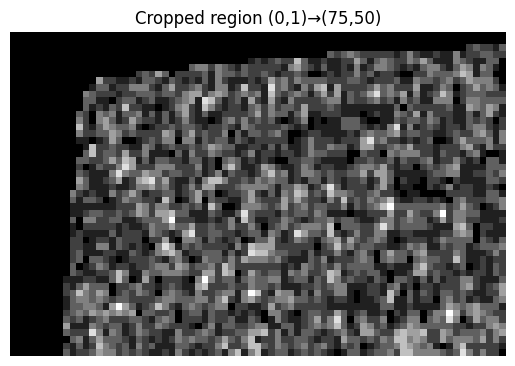

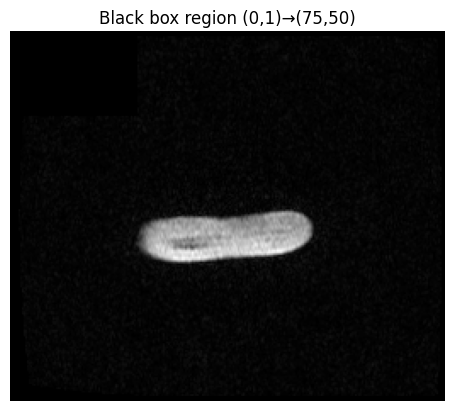

In [ ]:
if 'PixelData' in ds:
    arr = ds.pixel_array

    # random box for demo
    h, w = arr.shape
    x1, x2 = sorted(random.sample(range(w), 2))
    y1, y2 = sorted(random.sample(range(h), 2))

    # crop
    cropped = crop_image(ds, x1, y1, x2, y2)
    plt.imshow(cropped, cmap='gray')
    plt.title(f"Cropped region ({x1},{y1})→({x2},{y2})")
    plt.axis('off')
    plt.show()

    # blackout
    masked = blackout_region(ds, x1, y1, x2, y2)
    plt.imshow(masked, cmap='gray')
    plt.title(f"Black box region ({x1},{y1})→({x2},{y2})")
    plt.axis('off')
    plt.show()


# 7. Process and Save Your De-identified File

###Apply the mapping table to de-id selected metadata tags.

In [ ]:
# === Apply the DEID_MAP plan (optional one-click step) ===
def apply_plan(ds, plan):
    # A) clear
    if plan.get("clear"):
        ds = clear_tags(ds, plan["clear"])
    # B) mask
    if plan.get("mask"):
        ds = mask_tags(ds, plan["mask"])
    # C) generalize
    if plan.get("generalize"):
        ds = generalize_date(ds, plan["generalize"])
    # D) noise
    if plan.get("noise"):
        ds = noise_tags(ds, plan["noise"])
    # E) pseudonymize
    if plan.get("pseudonymize"):
        for t in plan["pseudonymize"]:
            T = _resolve_tag(t)
            if T in ds:
                ds[T].value = generate_pseudonym(ds[T].value, salt=plan.get("salt", ""))
    # F) suppress private
    if plan.get("suppress_private"):
        ds = suppress_private(ds)
    # Pixel masks (burned-in)
    if plan.get("pixel_masks"):
        if 'PixelData' in ds:
            arr = ds.pixel_array.copy()
            for (x1, y1, x2, y2) in plan["pixel_masks"]:
                arr[y1:y2, x1:x2] = 0
            ds.PixelData = arr.tobytes()
            ds.Rows, ds.Columns = arr.shape[:2]
    return ds

# Run-once example: apply plan to a copy and preview a few fields
ds_plan = ds.copy()
ds_plan = apply_plan(ds_plan, DEID_MAP)
print("AFTER applying DEID_MAP (sample of fields):")
for k, v in values_of(ds_plan, ["PatientID", "PatientName", "PatientBirthDate", "StudyDate", "InstitutionName"]).items():
    print(f"  {k}: {v}")


AFTER applying DEID_MAP (sample of fields):
  (0010,0020) PatientID: 4689a68532b0
  (0010,0010) PatientName: TEST^TEST
  (0010,0030) PatientBirthDate: 20011113
  (0008,0020) StudyDate: 20240408
  (0008,0080) InstitutionName: REDACTED HOSPITAL


In [ ]:
output_path = "deidentified_output.dcm"
ds.save_as(output_path)
print(f"\nSaved de-identified DICOM to: {output_path}")

# 9. Final Notes and Resources

Other useful tools/libraries:
- `dicom-anonymizer` (https://pypi.org/project/dicom-anonymizer/)
- `pyminc`, `nibabel` for NIfTI conversions
- `dcm2niix` (command-line tool for research pipelines)
- `pynetdicom` for secure DICOM transfer

Always test your de-identified files to ensure complete removal of PHI before sharing or publishing.
